In [1]:
! git clone "https://github.com/fraco03/DR_RETFound.git"
%cd "/kaggle/working/DR_RETFound"
! pwd


Cloning into 'DR_RETFound'...
remote: Enumerating objects: 194, done.
remote: Counting objects: 100% (194/194), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 194 (delta 131), reused 126 (delta 68), pack-reused 0 (from 0)
Receiving objects: 100% (194/194), 47.12 KiB | 3.62 MiB/s, done.
Resolving deltas: 100% (131/131), done.
/kaggle/working/DR_RETFound
/kaggle/working/DR_RETFound


In [2]:
!pip install grad-cam
import os
import pandas as pd
import numpy as np
import torch
import wandb
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import ConcatDataset, DataLoader, WeightedRandomSampler
from src.utils import visualizza_attenzione_retfound
from src.dataset import RetinopathyDataset, get_transforms
from src.loss import SmoothL1Loss
from src.model_setup import build_retfound_regression

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=915f4ff0772b059ea30e90b987eca2e76dcbee2a787398bae4c4269e0f4e57c7
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
def build_config():
    return {
        'aptos_csv': '/kaggle/input/competitions/aptos2019-blindness-detection/train.csv',
        'messidor_csv': '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor_data.csv',
        'ddr_csv': '/kaggle/input/datasets/mariaherrerot/ddrdataset/DR_grading.csv',
        'aptos_img_dir': '/kaggle/input/competitions/aptos2019-blindness-detection/train_images',
        'messidor_img_dir': '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess',
        'ddr_img_dir': '/kaggle/input/datasets/mariaherrerot/ddrdataset/DR_grading/DR_grading',
        'weights_path': '/kaggle/input/models/fraco0344/retfound/pytorch/default/1/RETFound_mae_natureCFP.pth',
        'checkpoint_dir': 'weights',
        'test_size': 0.2,
        'random_state': 42,
        'batch_size': 32,
        'num_workers': 4,
        'epochs': 20,
        'lr': 1e-4,
        'weight_decay': 1e-4,
        'loss_beta': 1.0,
        'sampler': 'weighted',
        'num_classes': 5,
        'log_confusion_matrix': True,
        'use_wandb': True,
        'wandb_project': 'dr-retfound',
        'wandb_run_name': None,
        'patience': 2,
        'early_stop_patience': 5,
        'clahe': True,
    }

cfg = build_config()
cfg

{'aptos_csv': '/kaggle/input/competitions/aptos2019-blindness-detection/train.csv',
 'messidor_csv': '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor_data.csv',
 'ddr_csv': '/kaggle/input/datasets/mariaherrerot/ddrdataset/DR_grading.csv',
 'aptos_img_dir': '/kaggle/input/competitions/aptos2019-blindness-detection/train_images',
 'messidor_img_dir': '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess',
 'ddr_img_dir': '/kaggle/input/datasets/mariaherrerot/ddrdataset/DR_grading/DR_grading',
 'weights_path': '/kaggle/input/models/fraco0344/retfound/pytorch/default/1/RETFound_mae_natureCFP.pth',
 'checkpoint_dir': 'weights',
 'test_size': 0.2,
 'random_state': 42,
 'batch_size': 32,
 'num_workers': 4,
 'epochs': 20,
 'lr': 0.0001,
 'weight_decay': 0.0001,
 'loss_beta': 1.0,
 'sampler': 'weighted',
 'num_classes': 5,
 'log_confusion_matrix': True,
 'use_wandb': True,
 'wandb_project': 'dr-retfound',
 'wandb_run_name': None,
 'patience

In [4]:
def load_splits(cfg):
    df_messidor = pd.read_csv(cfg['messidor_csv'])
    df_aptos = pd.read_csv(cfg['aptos_csv'])
    df_ddr = pd.read_csv(cfg['ddr_csv'])

    aptos_train, aptos_val = train_test_split(
        df_aptos,
        test_size=cfg['test_size'],
        stratify=df_aptos['diagnosis'],
        random_state=cfg['random_state'],
    )

    messidor_train, messidor_val = train_test_split(
        df_messidor,
        test_size=cfg['test_size'],
        stratify=df_messidor['diagnosis'],
        random_state=cfg['random_state'],
    )
    
    ddr_train, ddr_val = train_test_split(
        df_ddr,
        test_size=cfg['test_size'],
        stratify=df_ddr['diagnosis'],
        random_state=cfg['random_state'],
    )

    return aptos_train, aptos_val, messidor_train, messidor_val, ddr_train, ddr_val

def build_datasets(cfg):
    aptos_train, aptos_val, messidor_train, messidor_val, ddr_train, ddr_val = load_splits(cfg)

    val_transform = get_transforms(is_train=False, clahe=cfg['clahe'])

    ds_aptos_val = RetinopathyDataset(
        aptos_val,
        cfg['aptos_img_dir'],
        transform=val_transform,
    )
    ds_messidor_val = RetinopathyDataset(
        messidor_val,
        cfg['messidor_img_dir'],
        transform=val_transform,
    )

    ds_ddr_val = RetinopathyDataset(
        ddr_val,
        cfg['ddr_img_dir'],
        transform=val_transform,
    )

    val_dataset = ConcatDataset([ds_messidor_val, ds_aptos_val, ds_ddr_val])

    return None, val_dataset

train_dataset, val_dataset = build_datasets(cfg)
len(val_dataset)

3587

In [5]:
def build_loaders(cfg, train_dataset, val_dataset):

    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg['batch_size'],
        shuffle=False,
        num_workers=cfg['num_workers'],
    )

    return None, val_loader

train_loader, val_loader = build_loaders(cfg, train_dataset, val_dataset)
len(val_loader)

113

In [6]:

from collections import OrderedDict

# 1. Costruisci lo scheletro usando i pesi base (come facevi prima)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = build_retfound_regression(cfg['weights_path'], device=device)

# ==========================================
# 2. INIEZIONE DEL MODELLO FINE-TUNED 
# ==========================================
# Inserisci qui il percorso del file .pt che hai salvato a fine addestramento (quello buono!)
finetuned_path = '/kaggle/input/models/fraco0344/my-retfound/pytorch/default/1/retfound.pt' 

print(f"Caricamento modello fine-tuned da: {finetuned_path}")
checkpoint = torch.load(finetuned_path, map_location=device)

# Il tuo salvataggio usava 'model_state' (come si vede dal tuo vecchio codice)
state_dict = checkpoint['model_state'] 

# Pulizia del DataParallel (rimuove "module.")
clean_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "")
    clean_state_dict[name] = v

# 3. Carica i pesi con STRICT=TRUE. 
# Se c'è un errore qui, il codice si ferma e ti avvisa, non passa sotto silenzio!
model.load_state_dict(clean_state_dict, strict=True)
model = model.to(device)
model.eval()

print("✅ Pesi del modello fine-tuned caricati con successo e pronti per l'inferenza!")

Caricamento modello fine-tuned da: /kaggle/input/models/fraco0344/my-retfound/pytorch/default/1/retfound.pt
✅ Pesi del modello fine-tuned caricati con successo e pronti per l'inferenza!


In [7]:
def apply_thresholds(y_pred, thresholds):
    """Applica le 4 soglie per categorizzare i valori continui in 5 classi."""
    y_pred_cls = np.zeros_like(y_pred)
    y_pred_cls[y_pred < thresholds[0]] = 0
    y_pred_cls[(y_pred >= thresholds[0]) & (y_pred < thresholds[1])] = 1
    y_pred_cls[(y_pred >= thresholds[1]) & (y_pred < thresholds[2])] = 2
    y_pred_cls[(y_pred >= thresholds[2]) & (y_pred < thresholds[3])] = 3
    y_pred_cls[y_pred >= thresholds[3]] = 4
    return y_pred_cls

def kappa_objective(thresholds, y_true, y_pred):
    """Obiettivo: Massimizzare solo il Cohen's Kappa."""
    if not np.all(np.diff(thresholds) > 0): # Forza le soglie a restare ordinate
        return 1e6
    y_pred_cls = apply_thresholds(y_pred, thresholds)
    return -cohen_kappa_score(y_true, y_pred_cls, weights='quadratic')

def medical_objective(thresholds, y_true, y_pred, fp_weight=1.0, fn_weight=15.0):
    """Obiettivo: Penalizzare Falsi Negativi + Mantenere buon Kappa globale."""
    if not np.all(np.diff(thresholds) > 0):
        return 1e6
    
    y_pred_cls = apply_thresholds(y_pred, thresholds)
    cm = confusion_matrix(y_true, y_pred_cls, labels=[0, 1, 2, 3, 4])
    
    # Falsi Negativi (Malati scambiati per Sani) e Falsi Positivi (Sani per Malati)
    fn_critici = cm[1:, 0].sum() 
    fp_critici = cm[0, 1:].sum()
    
    # Calcoliamo anche la Kappa per non distruggere le altre classi
    kappa = cohen_kappa_score(y_true, y_pred_cls, weights='quadratic')
    
    # LOSS = Penalità Errori Gravi - Kappa (vogliamo la loss più bassa possibile)
    loss = (fn_critici * fn_weight) + (fp_critici * fp_weight) - kappa
    return loss

In [25]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from scipy.optimize import minimize
import torch
import numpy as np
from tqdm import tqdm

def validate_and_optimize_thresholds(all_preds, all_labels, val_loader, device='cuda', cfg=cfg):

    # --- 1. Ottimizzazione KAPPA (Massima accuratezza) ---
    print("\nOttimizzazione per Massima Kappa...")
    initial_thresholds = [0.5, 1.5, 2.5, 3.5]
    res_kappa = minimize(
        kappa_objective, 
        initial_thresholds, 
        args=(all_labels, all_preds), 
        method='Nelder-Mead'
    )
    t_kappa = res_kappa.x
    kappa_val = -res_kappa.fun

    # --- 2. Ottimizzazione MEDICA (Sicurezza Clinica) ---
    # Pesiamo i Falsi Negativi (FN) 15 volte più dei Falsi Positivi (FP)
    print("Ottimizzazione per Sicurezza Clinica (Minimizzazione Falsi Negativi)...")
    res_med = minimize(
        medical_objective, 
        initial_thresholds, 
        args=(all_labels, all_preds, 1.0, 12.0), 
        method='Nelder-Mead'
    )
    t_med = res_med.x

    # --- Visualizzazione Risultati ---
    print("\n" + "="*30)
    print("RISULTATI OTTIMIZZAZIONE")
    print("="*30)
    print(f"Soglie Standard:  [0.5, 1.5, 2.5, 3.5]")
    print(f"Soglie Miglior Kappa: {np.round(t_kappa, 3)} (Kappa: {kappa_val:.4f})")
    print(f"Soglie Sicurezza:     {np.round(t_med, 3)}")
    print("="*30)

    # Calcoliamo le Confusion Matrix per confronto
    y_kappa = apply_thresholds(all_preds, t_kappa)
    y_med = apply_thresholds(all_preds, t_med)
    
    return {
        'all_labels': all_labels,
        'all_preds_continuous': all_preds,
        'thresholds_kappa': t_kappa,
        'thresholds_med': t_med,
        'cm_kappa': confusion_matrix(all_labels, y_kappa),
        'cm_med': confusion_matrix(all_labels, y_med)
    }

# Esempio di chiamata:
# results = validate_and_optimize_thresholds(model, val_loader, device, cfg)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score

def plot_comparison_results(results):
    """
    Crea un confronto visivo tra il metodo Kappa e il metodo Medico.
    """
    labels = results['all_labels']
    preds_cont = results['all_preds_continuous']
    
    # Calcolo classi e Kappa finale per i due metodi
    y_kappa = apply_thresholds(preds_cont, results['thresholds_kappa'])
    y_med = apply_thresholds(preds_cont, results['thresholds_med'])
    
    kappa_k = cohen_kappa_score(labels, y_kappa, weights='quadratic')
    kappa_m = cohen_kappa_score(labels, y_med, weights='quadratic')

    # Configurazione Grafica
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    class_names = [f'Grado {i}' for i in range(5)]

    # --- Matrice 1: Ottimizzazione Kappa ---
    sns.heatmap(results['cm_kappa'], annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title(f'Ottimizzazione Max Kappa\n(Quadratic Kappa: {kappa_k:.4f})')
    ax1.set_xlabel('Predetto')
    ax1.set_ylabel('Reale')

    # --- Matrice 2: Ottimizzazione Medica ---
    sns.heatmap(results['cm_med'], annot=True, fmt='d', cmap='Reds', 
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title(f'Ottimizzazione Sicurezza Clinica\n(Quadratic Kappa: {kappa_m:.4f})')
    ax2.set_xlabel('Predetto')
    ax2.set_ylabel('Reale')

    plt.tight_layout()
    plt.show()

    # --- Report Testuale ---
    print("\n" + "="*50)
    print("ANALISI COMPARATIVA DELLE SOGLIE")
    print("="*50)
    print(f"{'Metodo':<20} | {'Kappa':<10} | {'Soglie Ottimizzate'}")
    print("-" * 50)
    print(f"{'Max Kappa':<20} | {kappa_k:.4f}     | {np.round(results['thresholds_kappa'], 3)}")
    print(f"{'Sicurezza Clinica':<20} | {kappa_m:.4f}     | {np.round(results['thresholds_med'], 3)}")
    print("="*50)



In [10]:
model.eval()
model_device = next(model.parameters()).device
all_preds = []
all_labels = []

print("--- Avvio Inferenza su Validation Set ---")
with torch.no_grad():
    for images, labels in tqdm(val_loader):
        images = images.to(model_device)
        
        # Otteniamo l'output continuo (regressione)
        outputs = model(images)
        
        # Se il modello restituisce un tensore con più dimensioni, lo appiattiamo
        preds = outputs.squeeze().cpu().numpy()
        targets = labels.cpu().numpy()
        
        # Gestione caso batch_size=1
        if preds.ndim == 0:
            all_preds.append(float(preds))
            all_labels.append(float(targets))
        else:
            all_preds.extend(preds)
            all_labels.extend(targets)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

--- Avvio Inferenza su Validation Set ---


100%|██████████| 113/113 [02:35<00:00,  1.38s/it]



Ottimizzazione per Massima Kappa...
Ottimizzazione per Sicurezza Clinica (Minimizzazione Falsi Negativi)...

RISULTATI OTTIMIZZAZIONE
Soglie Standard:  [0.5, 1.5, 2.5, 3.5]
Soglie Miglior Kappa: [0.627 1.371 2.388 3.318] (Kappa: 0.8659)
Soglie Sicurezza:     [0.083 1.322 2.818 4.584]


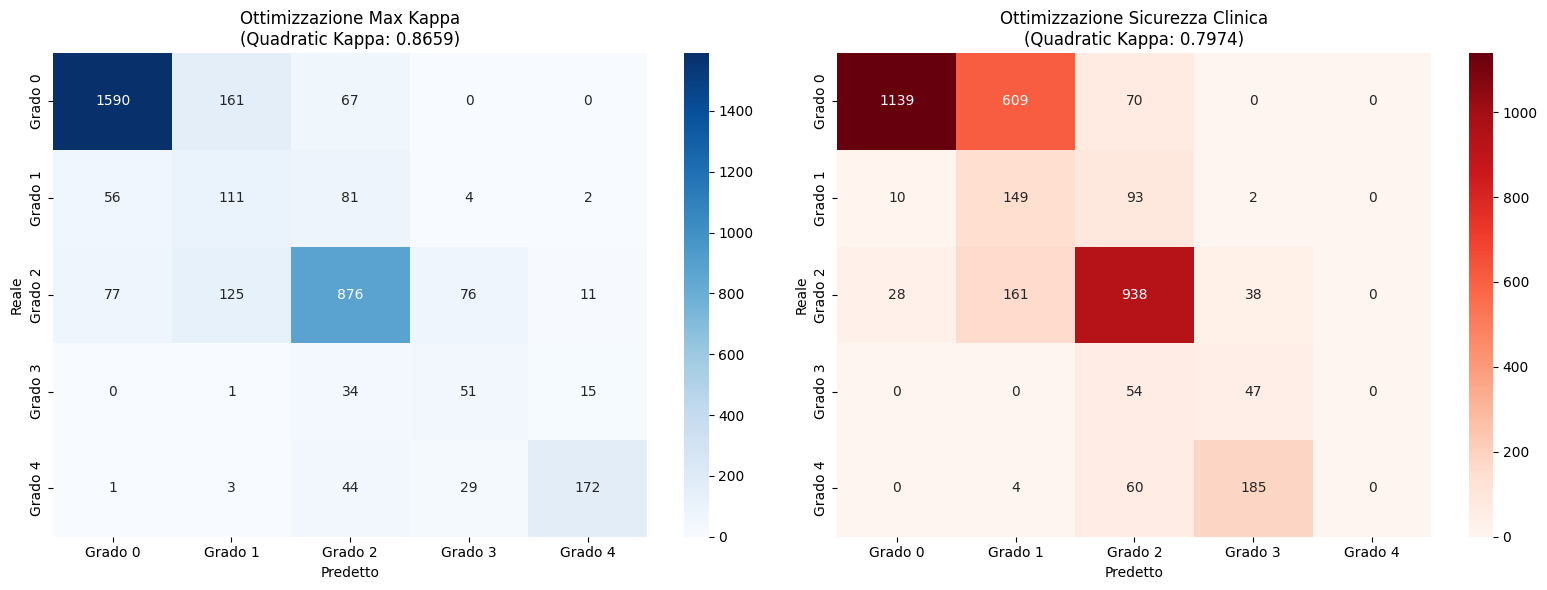


ANALISI COMPARATIVA DELLE SOGLIE
Metodo               | Kappa      | Soglie Ottimizzate
--------------------------------------------------
Max Kappa            | 0.8659     | [0.627 1.371 2.388 3.318]
Sicurezza Clinica    | 0.7974     | [0.083 1.322 2.818 4.584]


In [26]:

results = validate_and_optimize_thresholds(all_preds, all_labels, val_loader, device='cuda', cfg=cfg)
plot_comparison_results(results)